# Part I

Here, we work with vector-valued functions.  In this case, the dimension of the vector is the number of neurons in a simulation of an insect antennal lobe.  You will be working with the 75 neurons in the excitatory population when three different odors are presented.  (An odor stimulates a unique set of neurons.)  The insect's goal is to distinguish between different odors.

This data comes from the publication:
 Pyzza, P.B., Newhall, K.A., Kovačič, G. et al. Network mechanism for insect olfaction. Cogn Neurodyn 15, 103–129 (2021). https://doi.org/10.1007/s11571-020-09640-3

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# read in the data - average firing rate
# there are 75 excitatory neurons
# spikes are binned into 50 ms time intervals, averaged over 50 runs

odor1 = pd.read_csv('odor_1.csv', header=None)
odor1.head()

Out[2]: 
    0    1    2    3    4    5    6   ...   68   69  70   71   72   73   74
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   0  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   0  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   0  0.0  0.0  0.0  0.0

[5 rows x 75 columns]


In [3]:
dt = 50 #ms
Tmax = 4000 #ms
t = np.arange(0, Tmax, dt)



**Problem 1** [5 pts] Plot the average firing rate of a single neuron



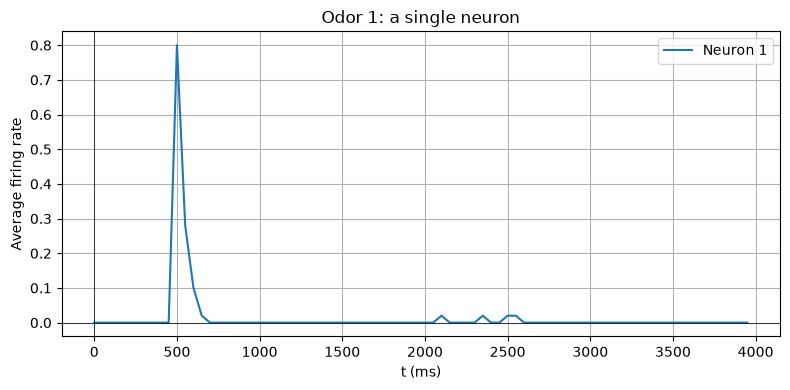

In [4]:
# Plot neuron 1 (column 0) over time.
plt.figure(figsize=(8, 4))
plt.plot(t, odor1.iloc[:, 0], label='Neuron 1')
plt.xlabel('t (ms)')
plt.ylabel('Average firing rate')
plt.title('Odor 1: a single neuron')
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

**Problem 2** [5 pts] Average the average firing rate over all the neurons to create a population average

In [5]:
# Average across the 75 neuron columns at each time point.
odor1_population = odor1.mean(axis=1)
odor1_population.head()

Out[5]: 
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
dtype: float64


**Problem 3** [5 pts] Plot the average firing rate of all the neurons

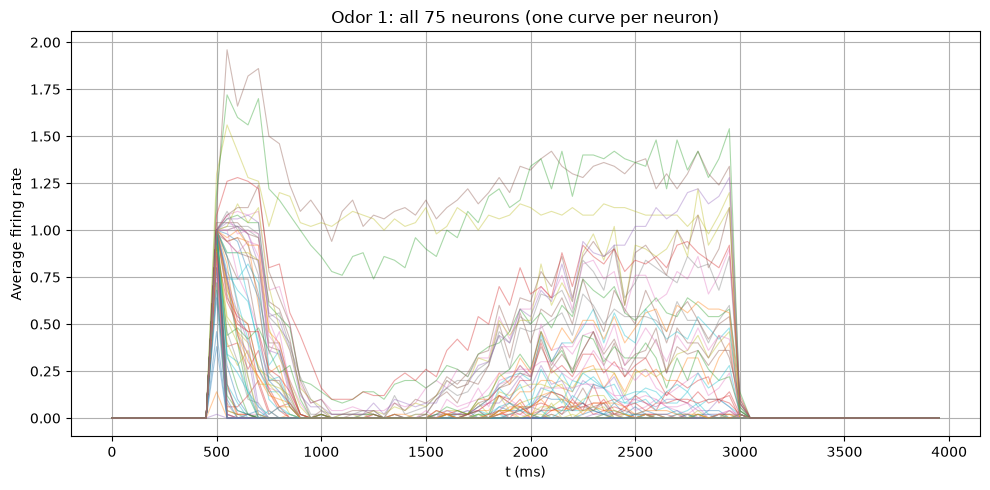

In [6]:
plt.figure(figsize=(10, 5))
for neuron in odor1.columns:
    plt.plot(t, odor1[neuron], alpha=0.4, linewidth=0.8)
plt.xlabel('t (ms)')
plt.ylabel('Average firing rate')
plt.title('Odor 1: all 75 neurons (one curve per neuron)')
plt.grid(True)
plt.tight_layout()
plt.show()

**Problem 4** [10 pts] Repeat for odors 2 and 3, creating a single plot with all three population averages.  Be sure to include lengends and axis labels.

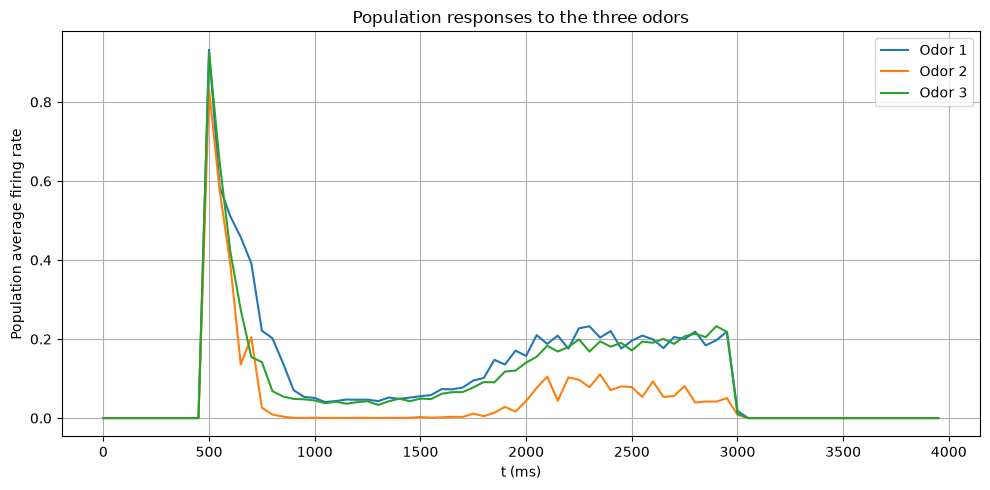

In [7]:
# These two files store neurons in rows and time points in columns.
# Transpose so all three data sets have shape (80 time points, 75 neurons).
odor2 = pd.read_csv('odor_2.csv', header=None).T
odor3 = pd.read_csv('odor_3.csv', header=None).T
assert odor1.shape == odor2.shape == odor3.shape == (len(t), 75)

odor2_population = odor2.mean(axis=1)
odor3_population = odor3.mean(axis=1)

plt.figure(figsize=(10, 5))
for population, label, color in zip(
    [odor1_population, odor2_population, odor3_population],
    ['Odor 1', 'Odor 2', 'Odor 3'],
    ['tab:blue', 'tab:orange', 'tab:green'],
):
    plt.plot(t, population, label=label, color=color)
plt.xlabel('t (ms)')
plt.ylabel('Population average firing rate')
plt.title('Population responses to the three odors')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Part II

PCA is not just for individual data points, we can use it on vector-valued functions as well.

In [8]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

**Problem 5** [5 pts]

Obtain the first 3 PCA components of the individual neuron firing rate data.

Here, we treat each time point (each row) like an individual data point.  Save the PCA components as `odor1_reduced`



In [9]:
# Each row is a time point; the 75 neuron firing rates are the features.
pca1 = PCA(n_components=3)
odor1_reduced = pca1.fit_transform(odor1)
print('Reduced shape:', odor1_reduced.shape)
print('Explained variance ratios:', pca1.explained_variance_ratio_)
print(f'Total variance explained: {pca1.explained_variance_ratio_.sum():.1%}')

Reduced shape: (80, 3)
Explained variance ratios: [0.72694741 0.1640159  0.05806832]
Total variance explained: 94.9%


Here we plot the temporal evolution of the three PCA components

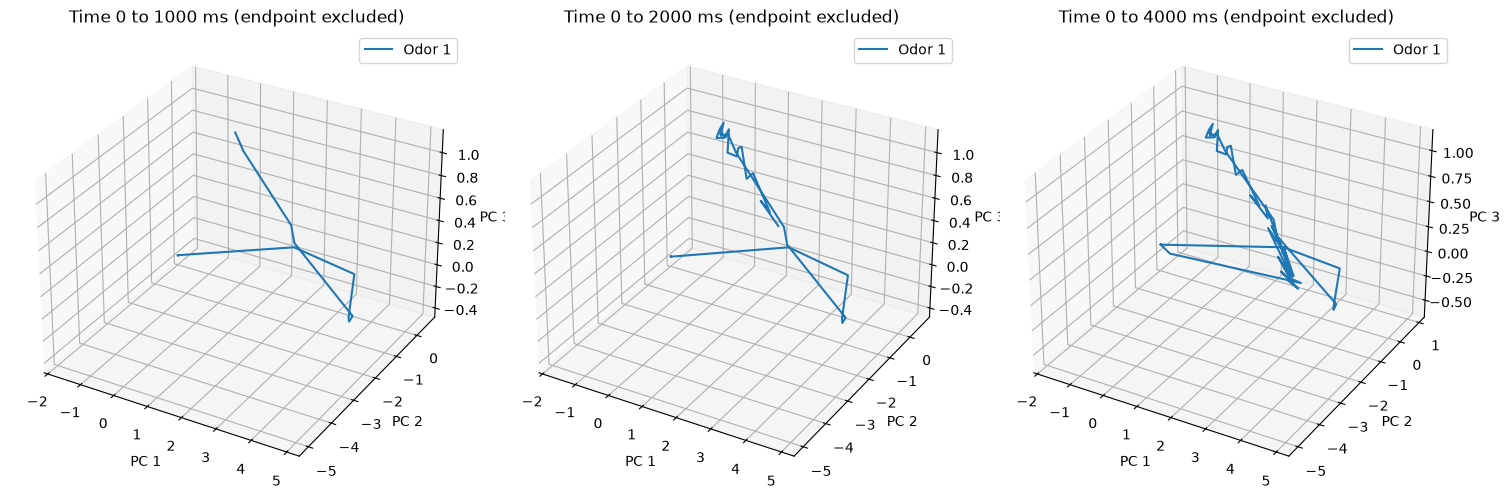

In [10]:
# Plot the odor 1 trajectory over progressively longer time windows.
fig = plt.figure(figsize=(15, 5))
for panel, stop in enumerate([20, 40, 80], start=1):
    ax = fig.add_subplot(1, 3, panel, projection='3d')
    ax.plot(*odor1_reduced[:stop].T, color='tab:blue', label='Odor 1')
    ax.set_title(f'Time 0 to {stop * dt} ms (endpoint excluded)')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_zlabel('PC 3')
    ax.legend()
plt.tight_layout()
plt.show()

**Problem 6** [10 pts]

Repeat with odors 2 and 3 and plot all three on the same plots.  Be sure to include lengends and axis labels.

Shared PCA explained variance ratios: [0.52805558 0.23292173 0.12550299]
Total variance explained: 88.6%


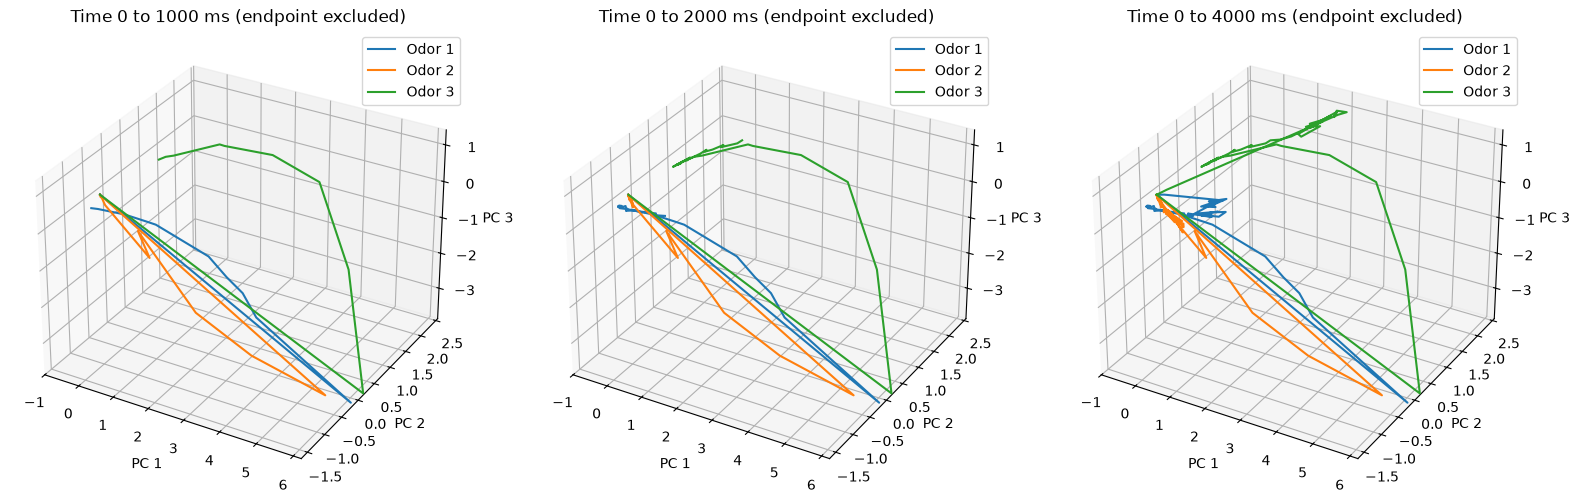

In [11]:
# Fit one PCA to the pooled time points so all odors share the same axes.
# Separate PCA fits would give different axes, making overlays misleading.
all_odors = np.vstack([odor1.to_numpy(), odor2.to_numpy(), odor3.to_numpy()])
pca_shared = PCA(n_components=3)
all_reduced = pca_shared.fit_transform(all_odors)
odor1_shared, odor2_reduced, odor3_reduced = np.split(all_reduced, 3)
print('Shared PCA explained variance ratios:', pca_shared.explained_variance_ratio_)
print(f'Total variance explained: {pca_shared.explained_variance_ratio_.sum():.1%}')

# Keep the same limits in every panel to compare the time windows fairly.
limits = [(all_reduced[:, j].min(), all_reduced[:, j].max()) for j in range(3)]
fig = plt.figure(figsize=(16, 5))
for panel, stop in enumerate([20, 40, 80], start=1):
    ax = fig.add_subplot(1, 3, panel, projection='3d')
    for reduced, label, color in zip(
        [odor1_shared, odor2_reduced, odor3_reduced],
        ['Odor 1', 'Odor 2', 'Odor 3'],
        ['tab:blue', 'tab:orange', 'tab:green'],
    ):
        ax.plot(*reduced[:stop].T, label=label, color=color)
    ax.set_title(f'Time 0 to {stop * dt} ms (endpoint excluded)')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_zlabel('PC 3')
    ax.set_xlim(limits[0])
    ax.set_ylim(limits[1])
    ax.set_zlim(limits[2])
    ax.legend()
plt.tight_layout()
plt.show()

**Problem 7** [10 pts]

Look at your resulting pictures after Part I and Part II.  Comment on the ability to distinguish between different odors.

In Part I, all three population averages show a sharp peak at about 500 ms. Odors 1 and 3 have similar peak rates (about 0.93 and 0.92), while odor 2 has a slightly lower peak (about 0.83) and a much shorter response. Their later responses differ, but the population averages overlap substantially, especially for odors 1 and 3. Averaging across neurons loses information about which neurons respond, so a population average alone does not clearly distinguish every odor at every time.

In Part II, the trajectories in the shared PCA coordinate system separate more clearly after the initial response: odors 1 and 3 move in different directions, particularly along PC 2, while odor 2 returns close to baseline sooner. The first three shared components retain about 88.6% of the variance, so they preserve much of the variation in the 75-neuron activity patterns. This suggests that the pattern of activity across neurons provides more information for distinguishing odors than the population average. The trajectories still overlap near baseline and during part of the initial response, so the plots do not establish perfect classification. Because these data are averaged over 50 runs, evaluating reliability on individual trials would require the trial-level data.